RBF神经网络 - 糖尿病预测
样本数: 442, 特征数: 10
目标范围: 25.0 - 346.0, 均值: 152.1

训练集: 353样本, 测试集: 89样本

训练RBF网络...

训练集 R² = 0.5017, MAE = 44.22
测试集 R² = 0.4803, MAE = 42.21

------------------------------------------------------------
测试集前10个预测结果
------------------------------------------------------------
序号	真实值	预测值	误差	相对误差
0	219.0	166.9	52.1	23.8%
1	70.0	171.6	101.6	145.1%
2	202.0	162.0	40.0	19.8%
3	230.0	212.6	17.4	7.6%
4	111.0	97.1	13.9	12.5%
5	84.0	143.5	59.5	70.9%
6	242.0	253.4	11.4	4.7%
7	272.0	210.0	62.0	22.8%
8	94.0	109.7	15.7	16.7%
9	96.0	117.7	21.7	22.6%


d:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7244\2148812707.py:137: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


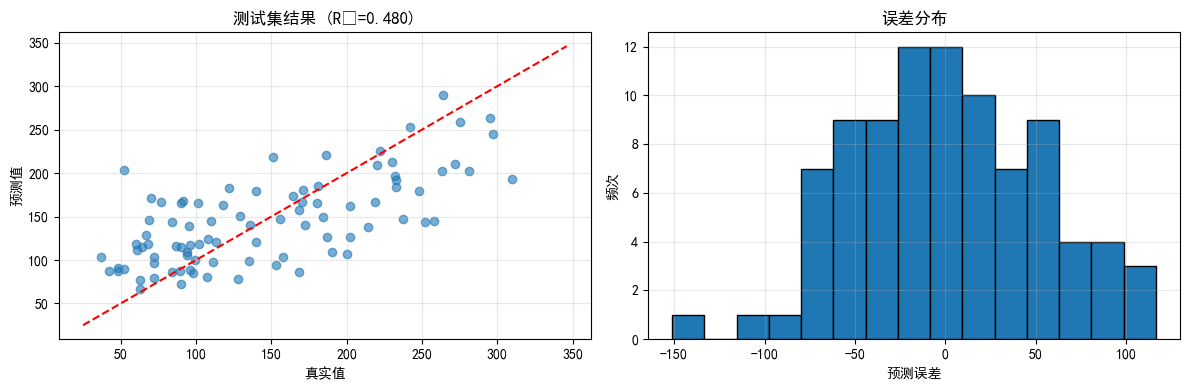

In [5]:
# coding=utf-8
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt

class RBFNN:
    def __init__(self, hidden_neurons=20, lambda_reg=0.1):
        self.hidden_neurons = hidden_neurons
        self.lambda_reg = lambda_reg
        self.centers = None
        self.widths = None
        self.weights = None
        self.scaler_X = StandardScaler()
        self.scaler_y = StandardScaler()
        
    def _gaussian(self, x, center, width):
        return np.exp(-np.sum((x - center) ** 2) / (2 * max(width, 0.1) ** 2))
    
    def _calculate_widths(self, centers):
        n_centers = len(centers)
        widths = np.ones(n_centers)
        for i in range(n_centers):
            distances = [np.linalg.norm(centers[i] - centers[j]) 
                        for j in range(n_centers) if j != i]
            if distances:
                widths[i] = np.median(distances) * 0.5
        return widths
    
    def _compute_basis(self, X):
        n_samples = len(X)
        n_centers = len(self.centers)
        basis = np.ones((n_samples, n_centers + 1))
        for i in range(n_samples):
            for j in range(n_centers):
                basis[i, j + 1] = self._gaussian(X[i], self.centers[j], self.widths[j])
        return basis
    
    def fit(self, X, y):
        X_scaled = self.scaler_X.fit_transform(X)
        y_scaled = self.scaler_y.fit_transform(y.reshape(-1, 1)).ravel()
        
        kmeans = KMeans(n_clusters=self.hidden_neurons, random_state=42, n_init=10)
        kmeans.fit(X_scaled)
        self.centers = kmeans.cluster_centers_
        self.widths = self._calculate_widths(self.centers)
        
        basis = self._compute_basis(X_scaled)
        XTX = basis.T @ basis
        XTY = basis.T @ y_scaled
        I = np.eye(XTX.shape[0])
        self.weights = np.linalg.solve(XTX + self.lambda_reg * I, XTY)
        return self
    
    def predict(self, X):
        X_scaled = self.scaler_X.transform(X)
        basis = self._compute_basis(X_scaled)
        y_pred_scaled = basis @ self.weights
        return self.scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    
    def score(self, X, y):
        return r2_score(y, self.predict(X))


# ================== 主程序 ==================

if __name__ == '__main__':
    # 1. 加载数据
    print("=" * 50)
    print("RBF神经网络 - 糖尿病预测")
    print("=" * 50)
    
    diabetes = load_diabetes()
    X, y = diabetes.data, diabetes.target
    feature_names = diabetes.feature_names
    
    print(f"样本数: {X.shape[0]}, 特征数: {X.shape[1]}")
    print(f"目标范围: {y.min():.1f} - {y.max():.1f}, 均值: {y.mean():.1f}")
    
    # 2. 划分数据集
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    print(f"\n训练集: {X_train.shape[0]}样本, 测试集: {X_test.shape[0]}样本")
    
    # 3. 训练模型
    print("\n训练RBF网络...")
    rbf = RBFNN(hidden_neurons=20, lambda_reg=0.1)
    rbf.fit(X_train, y_train)
    
    # 4. 预测
    y_train_pred = rbf.predict(X_train)
    y_test_pred = rbf.predict(X_test)
    
    # 5. 评估
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    print(f"\n训练集 R² = {train_r2:.4f}, MAE = {train_mae:.2f}")
    print(f"测试集 R² = {test_r2:.4f}, MAE = {test_mae:.2f}")
    
    # 6. 显示部分预测结果
    print("\n" + "-" * 60)
    print("测试集前10个预测结果")
    print("-" * 60)
    print("序号\t真实值\t预测值\t误差\t相对误差")
    for i in range(min(10, len(y_test))):
        err = abs(y_test[i] - y_test_pred[i])
        rel_err = err / y_test[i] * 100
        print(f"{i}\t{y_test[i]:.1f}\t{y_test_pred[i]:.1f}\t{err:.1f}\t{rel_err:.1f}%")
    
    # 7. 简单可视化
    plt.figure(figsize=(12, 4))
    
    # 预测vs真实
    plt.subplot(1, 2, 1)
    plt.scatter(y_test, y_test_pred, alpha=0.6)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    plt.xlabel('真实值')
    plt.ylabel('预测值')
    plt.title(f'测试集结果 (R²={test_r2:.3f})')
    plt.grid(True, alpha=0.3)
    
    # 误差分布
    plt.subplot(1, 2, 2)
    plt.hist(y_test - y_test_pred, bins=15, edgecolor='black')
    plt.xlabel('预测误差')
    plt.ylabel('频次')
    plt.title('误差分布')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [4]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号